In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("/content/Hospital_Appointment_Waiting_Time_Synthetic_Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (100000, 12)


,department,doctor,appointment_type,patient_type,insurance_type,urgency,visit_mode,payment_type,visit_status,queue_position,consultation_duration,waiting_time
0,ENT,Dr. Singh,Follow-up,Returning,Private,Low,In-Person,Insurance,Waiting,27,19,123
1,General Medicine,Dr. Singh,Routine,New,Government,Low,Teleconsultation,UPI,Scheduled,3,13,33
2,ENT,Dr. Rao,Consultation,Returning,Self-Pay,Low,In-Person,Card,Waiting,6,19,74
3,Neurology,Dr. Patel,Consultation,Returning,Self-Pay,Medium,In-Person,UPI,Completed,7,28,39
4,Pediatrics,Dr. Sharma,Consultation,Returning,Corporate,Low,In-Person,Card,Waiting,27,19,130


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all"))

Dataset Shape: (100000, 12)

Column Names:
['department', 'doctor', 'appointment_type', 'patient_type', 'insurance_type', 'urgency', 'visit_mode', 'payment_type', 'visit_status', 'queue_position', 'consultation_duration', 'waiting_time']

Data Types:
department               object
doctor                   object
appointment_type         object
patient_type             object
insurance_type           object
urgency                  object
visit_mode               object
payment_type             object
visit_status             object
queue_position            int64
consultation_duration     int64
waiting_time              int64
dtype: object

Missing Values:
department               0
doctor                   0
appointment_type         0
patient_type             0
insurance_type           0
urgency                  0
visit_mode               0
payment_type             0
visit_status             0
queue_position           0
consultation_duration    0
waiting_time             0
dtype: int

,department,doctor,appointment_type,patient_type,insurance_type,urgency,visit_mode,payment_type,visit_status,queue_position,consultation_duration,waiting_time
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000
unique,8,8,4,3,4,4,2,4,3,NaN,NaN,NaN
top,Neurology,Dr. Khan,Routine,Returning,Private,Medium,In-Person,UPI,Completed,NaN,NaN,NaN
freq,12640,12742,42033,49850,34874,39935,85223,34834,59830,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.455580,21.009130,75.339510
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.682648,7.094796,30.372782
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,5.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000000,16.000000,52.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,20.000000,75.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,25.000000,99.000000


In [4]:
X = df.drop("waiting_time", axis=1)
y = df["waiting_time"]

print("Features:")
print(X.columns.tolist())

print("\nTarget: waiting_time")

Features:
['department', 'doctor', 'appointment_type', 'patient_type', 'insurance_type', 'urgency', 'visit_mode', 'payment_type', 'visit_status', 'queue_position', 'consultation_duration']

Target: waiting_time


In [5]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['queue_position', 'consultation_duration']

Categorical Features:
['department', 'doctor', 'appointment_type', 'patient_type', 'insurance_type', 'urgency', 'visit_mode', 'payment_type', 'visit_status']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 11)
Testing data: (20000, 11)


In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Elastic Net": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

In [9]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "Pipeline": pipeline,
        "Predictions": y_pred
    }

    print("\n", name)
    print("MAE      :", round(mae, 4))
    print("MSE      :", round(mse, 4))
    print("RMSE     :", round(rmse, 4))
    print("R2 Score :", round(r2, 4))


 Linear Regression
MAE      : 6.4261
MSE      : 64.2987
RMSE     : 8.0186
R2 Score : 0.9295

 Ridge Regression
MAE      : 6.4261
MSE      : 64.2984
RMSE     : 8.0186
R2 Score : 0.9295

 Lasso Regression
MAE      : 6.4263
MSE      : 64.3038
RMSE     : 8.019
R2 Score : 0.9295

 Elastic Net
MAE      : 6.4359
MSE      : 64.4676
RMSE     : 8.0292
R2 Score : 0.9293


In [10]:
comparison = pd.DataFrame({
    name: {
        "MAE": data["MAE"],
        "MSE": data["MSE"],
        "RMSE": data["RMSE"],
        "R2 Score": data["R2 Score"]
    }
    for name, data in results.items()
}).T

comparison

,MAE,MSE,RMSE,R2 Score
Linear Regression,6.426110,64.298657,8.018644,0.929470
Ridge Regression,6.426107,64.298442,8.018631,0.929471
Lasso Regression,6.426348,64.303810,8.018966,0.929465
Elastic Net,6.435855,64.467592,8.029171,0.929285


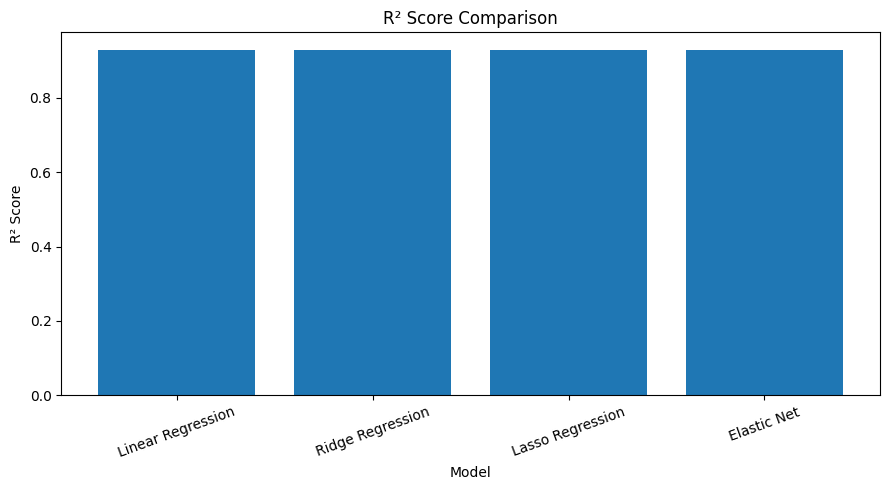

In [11]:
plt.figure(figsize=(9, 5))

plt.bar(comparison.index, comparison["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

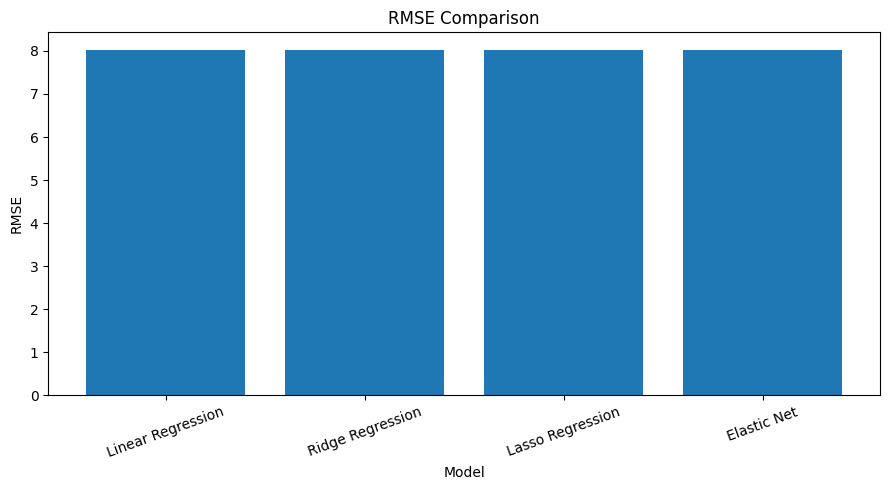

In [12]:
plt.figure(figsize=(9, 5))

plt.bar(comparison.index, comparison["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

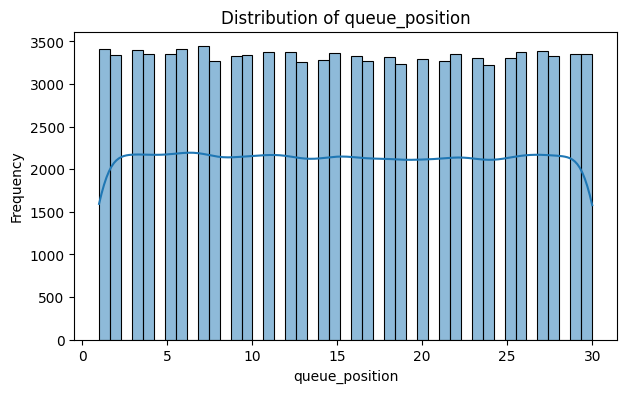

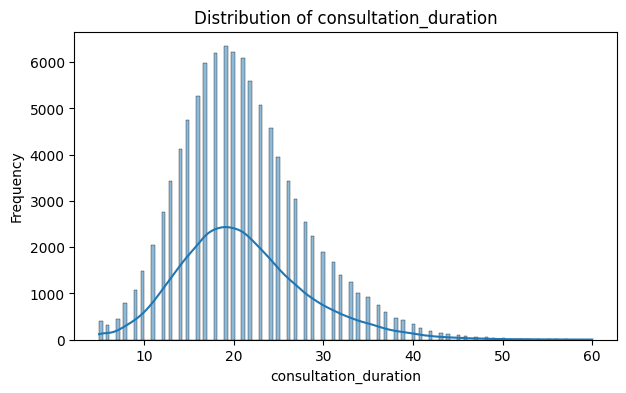

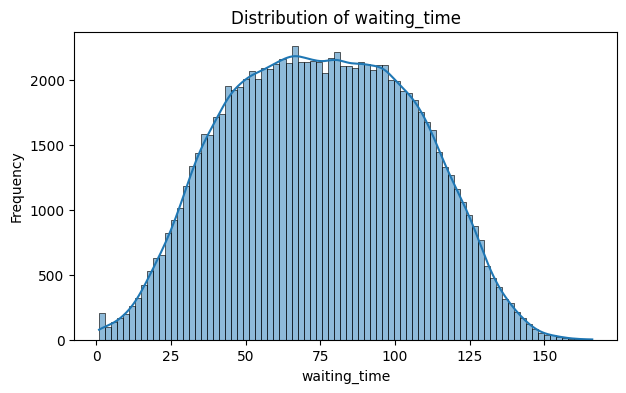

In [13]:
for column in numerical_features + ["waiting_time"]:

    plt.figure(figsize=(7, 4))

    sns.histplot(df[column], kde=True)

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

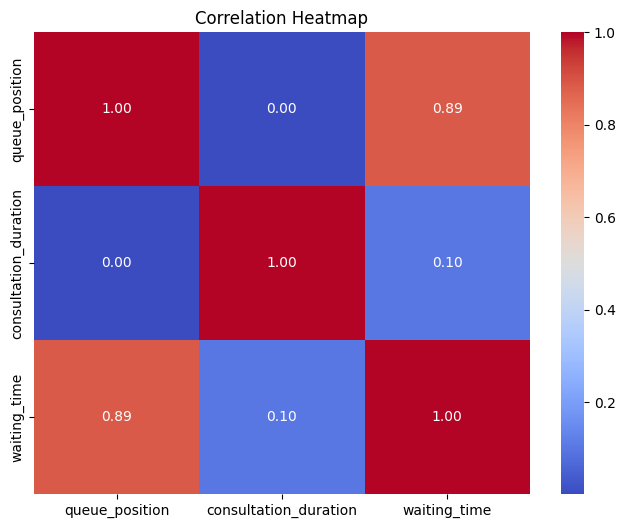

In [14]:
plt.figure(figsize=(8, 6))

correlation = df[numerical_features + ["waiting_time"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

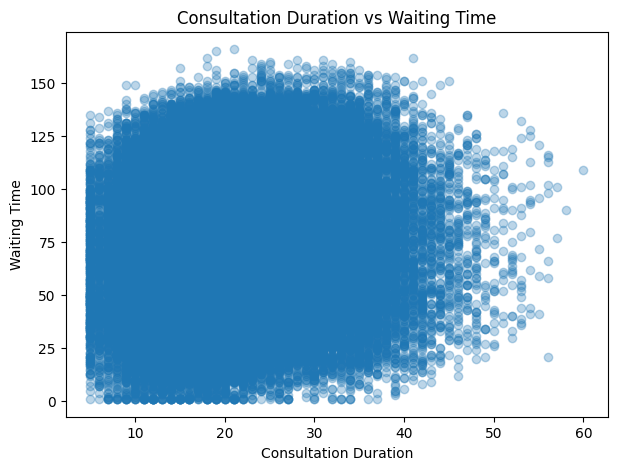

In [15]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["consultation_duration"],
    df["waiting_time"],
    alpha=0.3
)

plt.xlabel("Consultation Duration")
plt.ylabel("Waiting Time")
plt.title("Consultation Duration vs Waiting Time")

plt.show()

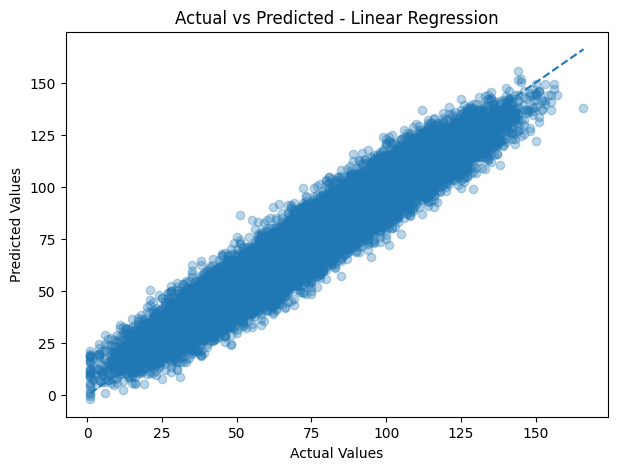

In [16]:
y_pred = results["Linear Regression"]["Predictions"]

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

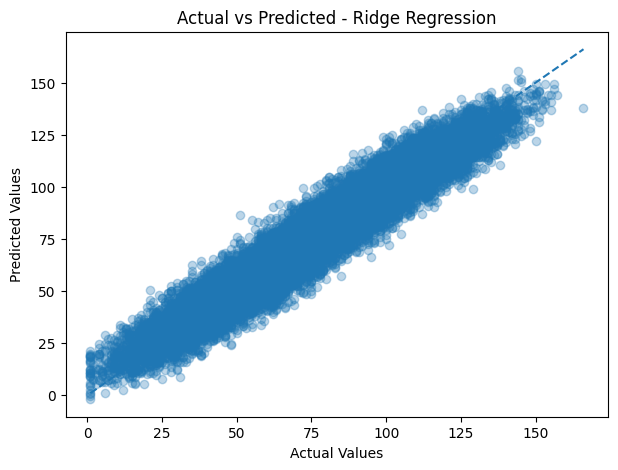

In [17]:
y_pred = results["Ridge Regression"]["Predictions"]

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Ridge Regression")

plt.show()

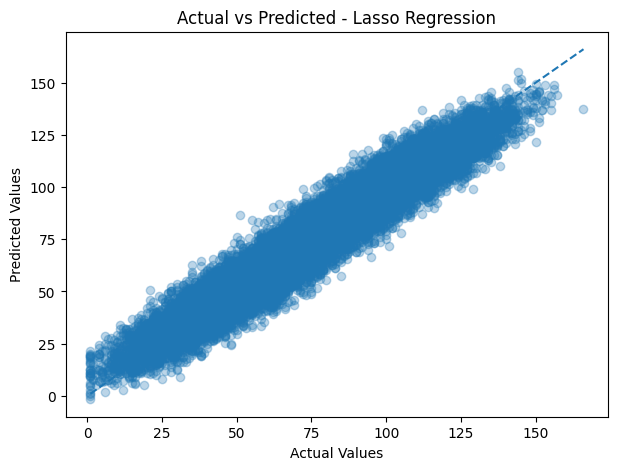

In [18]:
y_pred = results["Lasso Regression"]["Predictions"]

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Lasso Regression")

plt.show()

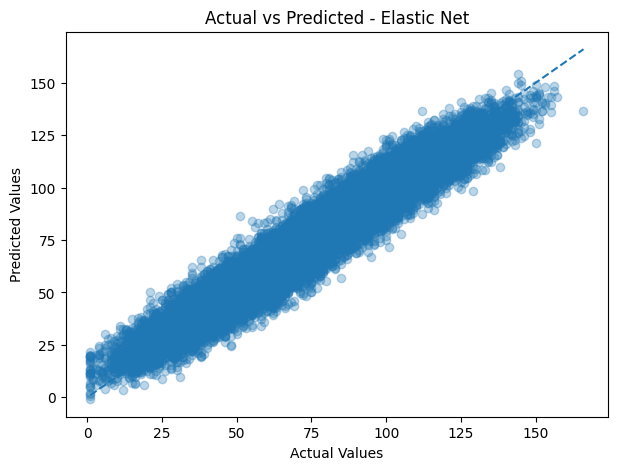

In [19]:
y_pred = results["Elastic Net"]["Predictions"]

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Elastic Net")

plt.show()

In [20]:
best_model = comparison["R2 Score"].idxmax()

print("Best Model:", best_model)
print("Best R² Score:", round(comparison.loc[best_model, "R2 Score"], 4))
print("Best RMSE:", round(comparison.loc[best_model, "RMSE"], 4))

Best Model: Ridge Regression
Best R² Score: 0.9295
Best RMSE: 8.0186


In [22]:
print("========== FINAL OBSERVATIONS ==========")

print("Best Model:", best_model)
print("Best R2 Score:", round(comparison.loc[best_model, "R2 Score"], 4))
print("Best RMSE:", round(comparison.loc[best_model, "RMSE"], 4))

print("\nRegularization:")
print("Ridge Regression applies L2 regularization.")
print("Lasso Regression applies L1 regularization.")
print("Elastic Net combines L1 and L2 regularization.")

========== FINAL OBSERVATIONS ==========
Best Model: Ridge Regression
Best R2 Score: 0.9295
Best RMSE: 8.0186

Regularization:
Ridge Regression applies L2 regularization.
Lasso Regression applies L1 regularization.
Elastic Net combines L1 and L2 regularization.
